In [68]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from flatbuffers.packer import float32
from tensorflow.keras.layers import Dense,Input
from tensorflow.keras import Sequential
from tensorflow.keras.losses import MeanSquaredError,BinaryCrossentropy
from tensorflow.keras.activations import sigmoid

import seaborn as sns
import logging

In [72]:
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)


x_train = np.array([[1.0], [2.0]], dtype=np.float32)
#X_train = np.array([[1.0], [2.0]], dtype=np.float32)
y_train = np.array([[300.0],[500.0]] , dtype=np.float32)



Text(0, 0.5, 'Price (in 1000s of dollars)')

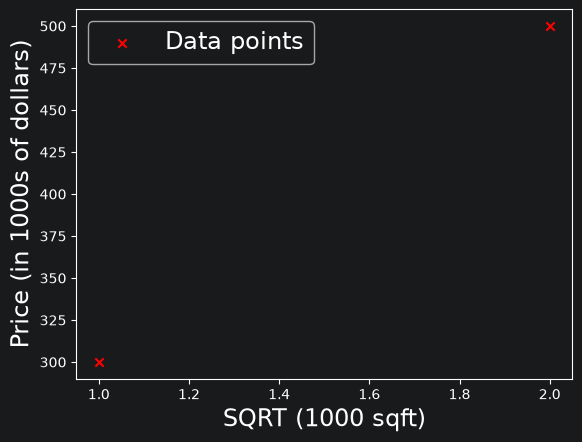

In [74]:
fig , ax = plt.subplots(1,1)
ax.scatter(x_train , y_train , marker='x',c='r',label='Data points')
ax.legend(fontsize='xx-large')
ax.set_xlabel('SQRT (1000 sqft)', fontsize='xx-large')
ax.set_ylabel('Price (in 1000s of dollars)',fontsize='xx-large')


# Regression/Linear model
The function implemented by a neuron with no activation is the same as in Coursera 1, linear regression :
$$ f_{\mathbf{w},b}(x^{(i)}) = \mathbf{w}\cdot x^{(i)} + b \tag{1}$$

In [75]:
linear_layer = tf.keras.layers.Dense(units=1 , activation='linear')
print(f"Linear layer : {linear_layer}")


Linear layer : <Dense name=dense_4, built=False>


In [76]:
linear_layer.get_weights()


[]

In [77]:
a1 = linear_layer(X_train[0].reshape(1,1))
print(f"a1 : {a1}")


a1 : [[0.]]


In [78]:
w,b = linear_layer.get_weights()
print(f"w : {w} , b : {b}")


w : [[-0.956619]] , b : [0.]


In [79]:
set_w = np.array([[200]])
set_b = np.array([100])

linear_layer.set_weights([set_w, set_b])

print(linear_layer.get_weights())

[array([[200.]], dtype=float32), array([100.], dtype=float32)]


In [80]:
a1 = linear_layer(X_train[0].reshape(1,1))
print(a1)

alin = np.dot(set_w,x_train[0].reshape(1,1)) + set_b
print(f"result is {alin}")

tf.Tensor([[100.]], shape=(1, 1), dtype=float32)
result is [[300.]]


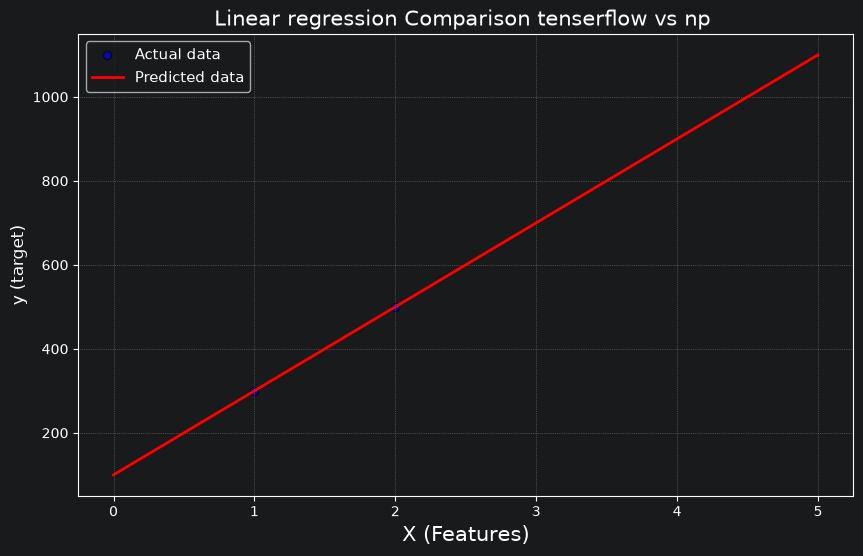

In [86]:
prediction_tf = linear_layer(X_train)
prediction_np = np.dot(X_train , set_w) + set_b
#plt_linear(X_train, Y_train, prediction_tf, prediction_np)

plt.figure(figsize=(10,6))
plt.scatter(x_train , y_train , color='b',label='Actual data' , alpha=0.6,edgecolors='k')

plt.plot(X_train, prediction_tf , color='r',linewidth=2,label='Predicted data')

#plt.plot(x_train , prediction_np , color='g',linewidth=2,label='Predicted data from np')


plt.title("Linear regression Comparison tenserflow vs np ", fontsize=15)
plt.xlabel('X (Features)' , fontsize=15)
plt.ylabel('y (target)',fontsize=12)
plt.legend(fontsize=11)
plt.grid(True,linestyle=':',alpha=0.6)

plt.show()

## Neuron with Sigmoid activation
The function implemented by a neuron/unit with a sigmoid activation is the same as in Course 1, logistic  regression:
$$ f_{\mathbf{w},b}(x^{(i)}) = g(\mathbf{w}x^{(i)} + b) \tag{2}$$
where $$g(x) = sigmoid(x)$$

Let's set $w$ and $b$ to some known values and check the model.


In [87]:
X_train = np.array([0. ,  1, 2, 3, 4, 5] , dtype=np.float32).reshape(-1,1)
Y_train = np.array([0. , 1, 1, 0, 0, 0] , dtype=np.float32).reshape(-1,1)


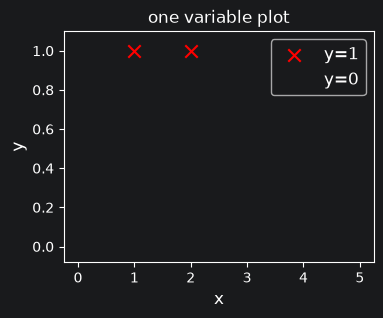

In [88]:
pos = Y_train == 1
neg = Y_train == 0

fig,ax = plt.subplots(1,1,figsize=(4,3))
ax.scatter(X_train[pos], Y_train[pos], marker='x', s=80, c = 'red', label="y=1")
ax.scatter(X_train[neg], Y_train[neg], marker='o', s=100, label="y=0", facecolors='none',lw=3)

ax.set_ylim(-0.08,1.1)
ax.set_ylabel('y', fontsize=12)
ax.set_xlabel('x', fontsize=12)
ax.set_title('one variable plot')
ax.legend(fontsize=12)
plt.show()

In [89]:
model = Sequential(
    [
        tf.keras.layers.Dense(1 , input_dim=1,activation='sigmoid' , name='L1')
    ]
)



In [90]:
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ L1 (Dense)                      │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [91]:
logistic_layer = model.get_layer('L1')
w,b = logistic_layer.get_weights()

print(f"w : {w} , b : {b}")
print(w.shape , b.shape)



w : [[0.27728307]] , b : [0.]
(1, 1) (1,)


In [94]:
set_w = np.array([[2]])
set_b = np.array([-4.5])
logistic_layer.set_weights([set_w, set_b])
print(logistic_layer.get_weights())


[array([[2.]], dtype=float32), array([-4.5], dtype=float32)]


In [95]:
a1 = model.predict(X_train[0].reshape(1,1))

print(a1)

alog = sigmoid(np.dot(set_w , X_train[0].reshape(1,1)) + set_b)
print(alog)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
[[0.01098694]]
tf.Tensor([[0.01098694]], shape=(1, 1), dtype=float64)
